# Gene Set Enrichment Analysis (GSEA)
# Phase 2 vs. Phase 2
with new ref genome

uses an entire ranked list (by log2FoldChange) of genes to see if pathway genes cluster at the top or bottom

#### Are *pathways* generally over- or under-expressed in a given treatment?

This method is somewhat preferred over over-representation analysis (ORA)

using [clusterProfiler](https://github.com/YuLab-SMU/clusterProfiler) R package


## 0. load libraries

In [2]:
library(tidyverse)
library(clusterProfiler) # for GSEA()
library(enrichplot) # for enrichment visuals
library(GO.db) # for gene ontology database
library(UpSetR) # for Cvirginica annotations
library(patchwork) # for arranging multiple plots

## 1. read in CSVs

read in GO annotation data

In [3]:
# col1 = gene ID
# col2 = GO ID 
gene2go <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ref_files/annotations/newRef_geneGO.csv')
head(gene2go)

,gene,Gene.Ontology.IDs
,<chr>,<chr>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655
2,LOC111099032,GO:0004930;GO:0005886;GO:0007186
3,LOC111099037,GO:0000978;GO:0000981;GO:0006355
4,LOC111099039,GO:0004930;GO:0005886;GO:0007189
5,LOC111099040,GO:0005515;GO:0007169;GO:0035556
6,LOC111099041,GO:0016020;GO:0022857;GO:0055085


re-format for correct input for `GSEA()` - two columns, one for GO term and one for gene ID

In [4]:
term2gene <- gene2go %>%
  mutate(GO_terms = strsplit(Gene.Ontology.IDs, ",\\s*|;\\s*|`")) %>%  # Split by comma, semicolon, or backtick
  unnest(GO_terms) %>%
  filter(grepl("^GO:", GO_terms)) %>%  # Keep only valid GO terms
  dplyr::select(term = GO_terms, gene = gene)

class(term2gene)
str(term2gene)
head(term2gene)

[1] "tbl_df"     "tbl"        "data.frame"

tibble [39,588 × 2] (S3: tbl_df/tbl/data.frame)
 $ term: chr [1:39588] "GO:0005261" "GO:0005886" "GO:0030001" "GO:0098655" ...
 $ gene: chr [1:39588] "LOC111099029" "LOC111099029" "LOC111099029" "LOC111099029" ...


term,gene
<chr>,<chr>
GO:0005261,LOC111099029
GO:0005886,LOC111099029
GO:0030001,LOC111099029
GO:0098655,LOC111099029
GO:0004930,LOC111099032
GO:0005886,LOC111099032


get term names for GO IDs

In [5]:
# Extract GO term descriptions
go_terms <- unique(term2gene$term)

# Get descriptions from GO.db
term2name <- data.frame(
  term = go_terms,
  name = sapply(go_terms, function(x) {
    tryCatch({
      Term(GOTERM[[x]])
    }, error = function(e) {
      NA_character_
    })
  })
)

# Remove NAs
term2name <- term2name[!is.na(term2name$name), ]

# View
head(term2name)    

,term,name
,<chr>,<chr>
GO:0005261,GO:0005261,monoatomic cation channel activity
GO:0005886,GO:0005886,plasma membrane
GO:0030001,GO:0030001,metal ion transport
GO:0098655,GO:0098655,monoatomic cation transmembrane transport
GO:0004930,GO:0004930,G protein-coupled receptor activity
GO:0007186,GO:0007186,G protein-coupled receptor signaling pathway


read in *all* genes from DESeq output (not just DEGs)

In [6]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res',
    pattern = '\\.csv$',
    full.names = TRUE
    )

head(files)

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bb_cc.csv"
[2] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bc_bb.csv"
[3] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bc_cc.csv"
[4] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bc_hc.csv"
[5] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bc_wc.csv"
[6] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bh_ch.csv"

In [7]:
names(files) <- tools::file_path_sans_ext(basename(files))
df_list <- lapply(files, read.csv)
names(df_list)
length(df_list)

[1] "bb_cc" "bc_bb" "bc_cc" "bc_hc" "bc_wc" "bh_ch" "bh_hh" "bw_cw" "bw_ww"
[10] "cb_bb" "cb_bc" "cb_cc" "cb_ch" "cb_cw" "ch_cc" "ch_hc" "cw_cc" "cw_ch"
[19] "cw_wc" "hb_bb" "hb_bh" "hb_cb" "hc_cc" "hc_hh" "hh_cc" "hh_ch" "wb_bb"
[28] "wb_bw" "wb_cb" "wc_cc" "wc_hc" "wc_ww" "wh_hw" "ww_cc" "ww_cw"

[1] 35

## 2. Formatting CSVs
input to `gsea()` is an order ranked geneList - I'm going to rank by log2FoldChange

In [8]:
# create numeric vector, ordered by LFC
all_df <- lapply(df_list, function(df) {
    geneList <- df$log2FoldChange 
    # Set gene IDs as names
    names(geneList) <- df$Gene
    
    # Sort in decreasing order
    geneList <- sort(geneList, decreasing = TRUE)

    return(geneList)
    })

# check things look okay 
head(all_df$bb_cc)

LOC111116266 LOC144619016 LOC144621941 LOC144619223 LOC111114643 LOC144619236 
    29.02691     25.92662     25.10785     23.73032     22.89080     22.63045

## 3. Run GSEA

Output notes [from here](https://www.gsea-msigdb.org/gsea/doc/GSEAUserGuideTEXT.htm):
- setSize
- enrichmentScore - degree to which the gene set is overrepresented at the top or bottom of a ranked list of genes (pos = top of list, neg = bottom of list)
- NES - normalized enrichment score; should be used to compare analysis results across gene sets
- qvalue - also FDR (false discovery rate)
- rank
- leading_edge - core group of genes that accounts for the gene set's enrichment signal
- core_enrichment - subset of genes that contributes most to the enrichment result

geneRatio - how much of a pathway (gene set) is represented in ranked genes that contribute to the enrichment signal

### 1. effect of single exposure after period of recovery
no enriched terms for any of the comparisons
- CC vs. WC
- CC vs. HC
- CC vs. BC

In [9]:
# CC vs. WC
gsea_res_cc.wc <- GSEA(
    geneList = all_df$wc_cc,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
as.data.frame(gsea_res_cc.wc)

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.55% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched GO terms

In [11]:
# CC vs. HC
gsea_res_cc.hc <- GSEA(
    geneList = all_df$hc_cc,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
as.data.frame(gsea_res_cc.hc)

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.77% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched GO terms

In [12]:
# CC vs. BC
gsea_res_cc.bc <- GSEA(
    geneList = all_df$bc_cc,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
as.data.frame(gsea_res_cc.bc)

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.03% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched GO terms

### 2. effect of single late exposure
- CC vs. CW
- CC vs. CH (no enriched terms)
- CC vs. CB


In [13]:
# CC vs. CW
gsea_res_cc.cw <- GSEA(
    geneList = all_df$cw_cc,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
as.data.frame(gsea_res_cc.cw)

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.79% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
leading edge analysis...

done...



,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>
GO:0008061,GO:0008061,chitin binding,56,0.988136,2.094404,6.004637e-05,0.03020332,0.03020332,121,"tags=4%, list=0%, signal=4%",LOC144619016/LOC144617818


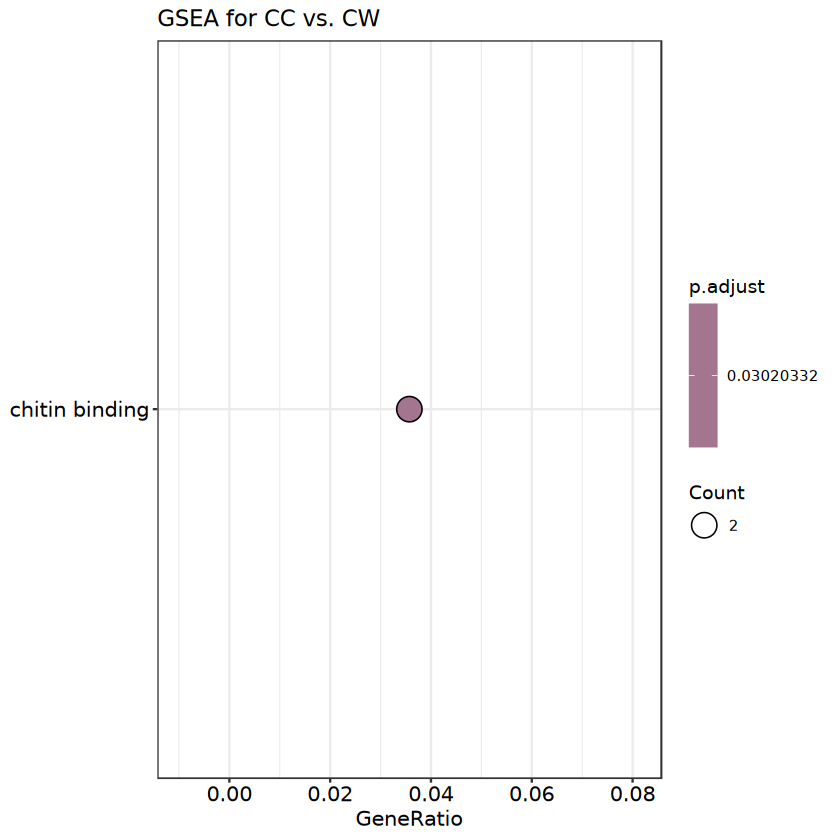

In [21]:
dotplot(gsea_res_cc.cw, showCategory=20) + ggtitle('GSEA for CC vs. CW')

chitin!!

In [14]:
# CC vs. CH
gsea_res_cc.ch <- GSEA(
    geneList = all_df$ch_cc,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
as.data.frame(gsea_res_cc.ch)

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.54% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched GO terms

In [15]:
# CC vs. CB
gsea_res_cc.cb <- GSEA(
    geneList = all_df$cb_cc,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
as.data.frame(gsea_res_cc.cb)

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.77% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
leading edge analysis...

done...



,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>
GO:0008061,GO:0008061,chitin binding,56,0.9748983,2.280245,2.817212e-05,0.01417058,0.01417058,1,"tags=2%, list=0%, signal=2%",LOC144619016


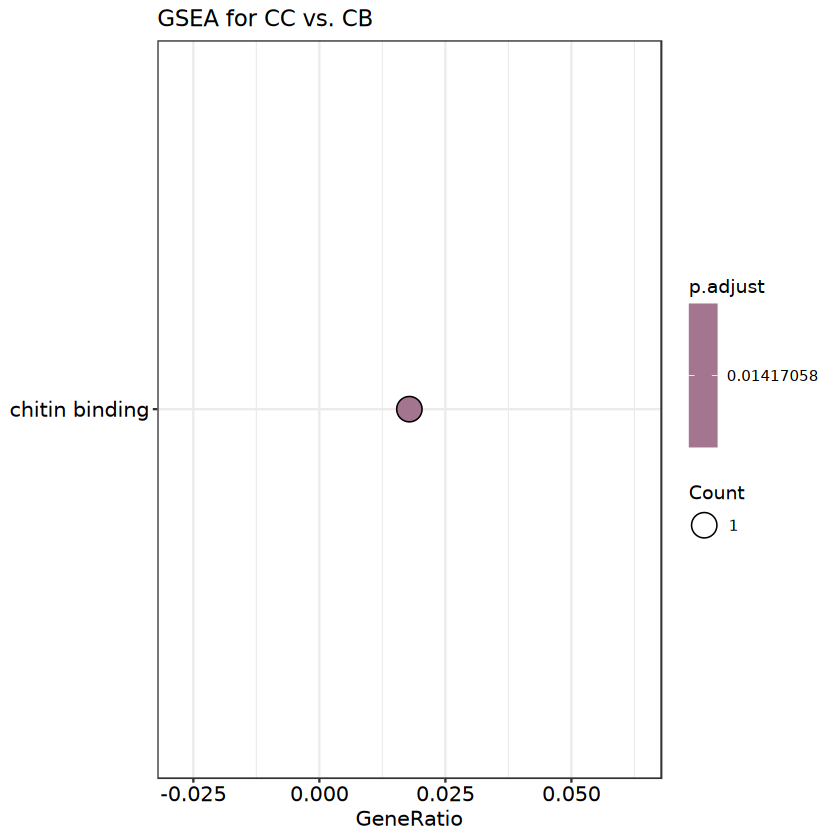

In [20]:
dotplot(gsea_res_cc.cb, showCategory=20) + ggtitle('GSEA for CC vs. CB')

more chitin!

so single late stress exposure in Both and Warming result in enrichment of chitin binding (but not hypoxia) - so likely temperature driven??

### 3. Effect of timing of initial stress exposure
- CW vs. WC (no enriched terms)
- CH vs. HC
- CB vs. BC (no enriched terms)

In [16]:
# CW vs. WC
gsea_res_cw.wc <- GSEA(
    geneList = all_df$cw_wc,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
as.data.frame(gsea_res_cw.wc)

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.6% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched GO terms

In [17]:
# HC vs. CH
gsea_res_ch.hc <- GSEA(
    geneList = all_df$ch_hc,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
as.data.frame(gsea_res_ch.hc)

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.54% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
leading edge analysis...

done...



,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
GO:0016705,GO:0016705,"oxidoreductase activity, acting on paired donors, with incorporation or reduction of molecular oxygen",32,-0.9984655,-1.792372,3.143971e-05,0.01581417,0.01581417,2,"tags=6%, list=0%, signal=6%",LOC111138426/LOC111100601
GO:0004497,GO:0004497,monooxygenase activity,26,-0.9987465,-1.862445,8.446118e-05,0.02124199,0.02124199,2,"tags=8%, list=0%, signal=8%",LOC111138426/LOC111100601


Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the enrichplot package.
  Please report the issue at
  <https://github.com/GuangchuangYu/enrichplot/issues>.”


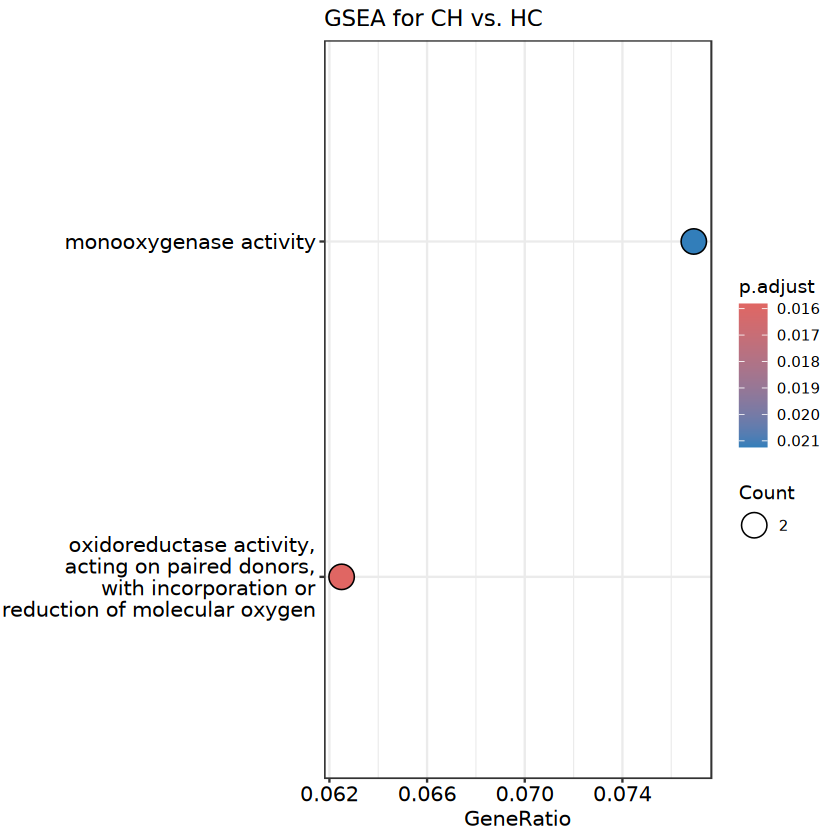

In [18]:
dotplot(gsea_res_ch.hc, showCategory=20) + ggtitle('GSEA for CH vs. HC')

seeing enrichment for processes related to oxygen - when looking at the timing of single hypoxic stress - interesting!! 

In [22]:
# CB vs. BC
gsea_res_cb.bc <- GSEA(
    geneList = all_df$cb_bc,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
as.data.frame(gsea_res_cb.bc)

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.05% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched GO terms

### 4. No stress vs. most stress
- CC vs. WW
- CC vs. HH (no enriched terms)
- CC vs. BB (no enriched terms)

In [23]:
# CC vs. WW
gsea_res_cc.ww <- GSEA(
    geneList = all_df$ww_cc,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_cc.ww))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.87% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
leading edge analysis...

done...



,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>
GO:0008061,GO:0008061,chitin binding,56,0.9981634,1.825323,2.665683e-06,0.001340839,0.001340839,1,"tags=2%, list=0%, signal=2%",LOC144619016


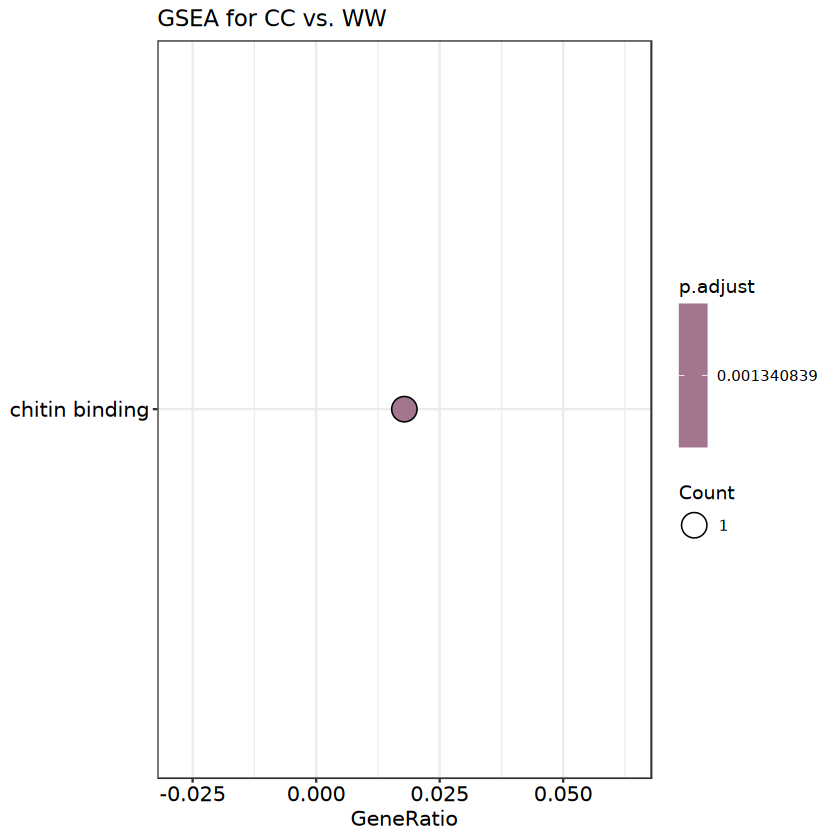

In [24]:
dotplot(gsea_res_cc.ww, showCategory=20) + ggtitle('GSEA for CC vs. WW')

moreeee chitin! and related to warming again (possibly late warming specifically??)

In [25]:
# CC vs. HH
gsea_res_cc.hh <- GSEA(
    geneList = all_df$hh_cc,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_cc.hh))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.03% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched GO terms

In [26]:
# CC vs. BB
gsea_res_cc.bb <- GSEA(
    geneList = all_df$bb_cc,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_cc.bb))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.51% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched GO terms

### 5. Effect of initial exposure on response in later exposure

#### A. matched priming
- WW vs. CW (no enriched terms)
- HH vs. CH (no enriched terms)
- BB vs. CB

In [27]:
# WW vs. CW
gsea_res_ww.cw <- GSEA(
    geneList = all_df$ww_cw,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_ww.cw))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.81% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched GO terms

In [28]:
# HH vs. CH
gsea_res_hh.ch <- GSEA(
    geneList = all_df$hh_ch,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_hh.ch))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.03% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched GO terms

In [29]:
# BB vs. CB
gsea_res_cb.bb <- GSEA(
    geneList = all_df$cb_bb,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_cb.bb))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.5% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
leading edge analysis...

done...



,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>
GO:0006355,GO:0006355,regulation of DNA-templated transcription,96,0.9976952,1.396889,3.916582e-05,0.01970041,0.01970041,8,"tags=1%, list=0%, signal=1%",LOC111127044


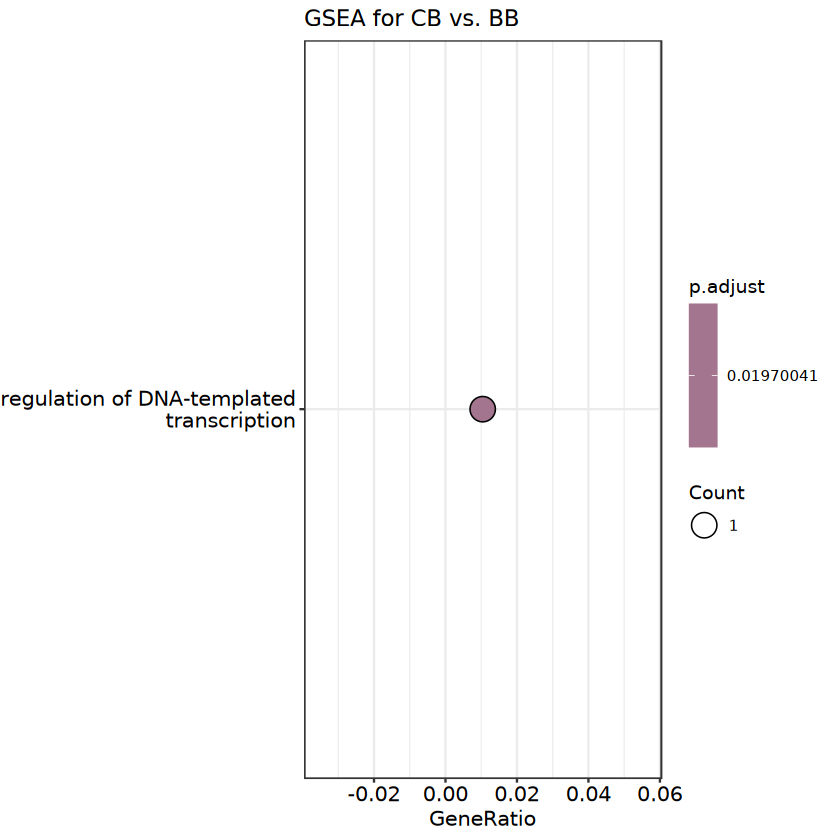

In [30]:
dotplot(gsea_res_cb.bb, showCategory=20) + ggtitle('GSEA for CB vs. BB')

#### B. semi-matched priming: in context of later single stress
- CH vs. BH 
- CW vs. BW (no enriched terms)

In [31]:
# CH vs. BH
gsea_res_ch.bh <- GSEA(
    geneList = all_df$bh_ch,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_ch.bh))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.28% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
leading edge analysis...

done...



,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
GO:0051045,GO:0051045,negative regulation of membrane protein ectodomain proteolysis,19,-0.9840597,-1.936990,1.876465e-05,0.005584533,0.005584533,93,"tags=21%, list=0%, signal=21%",LOC111110387/LOC111128126/LOC111110389/LOC111107102
GO:0008191,GO:0008191,metalloendopeptidase inhibitor activity,21,-0.9804939,-1.904010,3.330736e-05,0.005584533,0.005584533,159,"tags=19%, list=1%, signal=19%",LOC111106984/LOC111128126/LOC111110389/LOC111107102
GO:0002020,GO:0002020,protease binding,28,-0.9761139,-1.839966,2.469475e-05,0.005584533,0.005584533,93,"tags=14%, list=0%, signal=14%",LOC111110387/LOC111128126/LOC111110389/LOC111107102
GO:0010951,GO:0010951,negative regulation of endopeptidase activity,20,-0.9806734,-1.892347,1.589145e-04,0.012408715,0.012408715,93,"tags=20%, list=0%, signal=20%",LOC111110387/LOC111128126/LOC111110389/LOC111107102
GO:0000086,GO:0000086,G2/M transition of mitotic cell cycle,10,-0.9913458,-1.864054,1.726859e-04,0.012408715,0.012408715,7,"tags=20%, list=0%, signal=20%",LOC144624936/LOC111132581
GO:0010971,GO:0010971,positive regulation of G2/M transition of mitotic cell cycle,10,-0.9913458,-1.864054,1.726859e-04,0.012408715,0.012408715,7,"tags=20%, list=0%, signal=20%",LOC144624936/LOC111132581


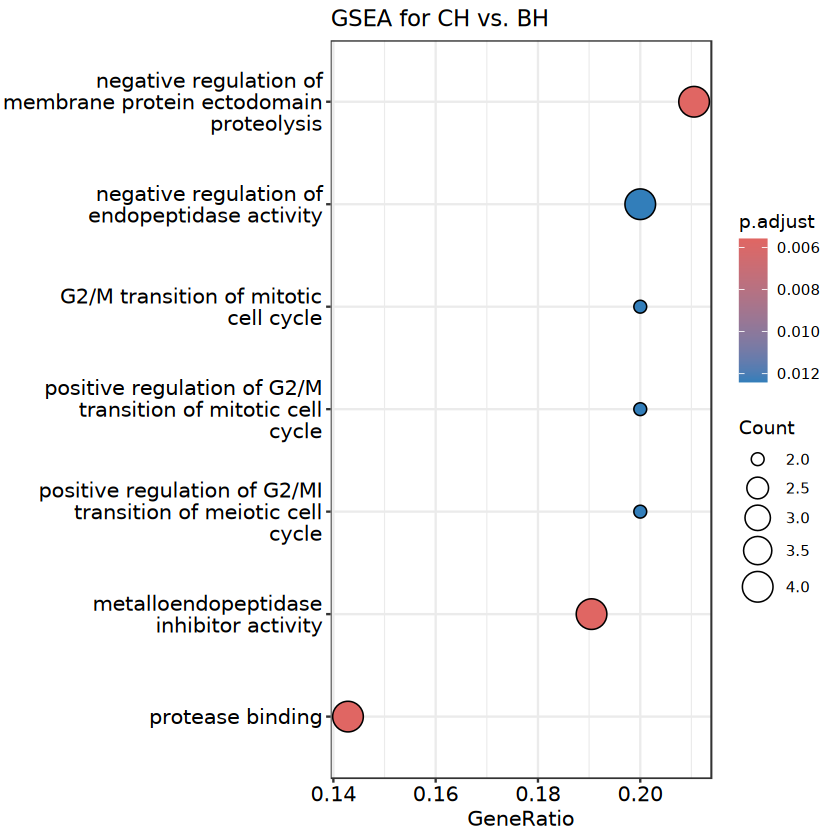

In [32]:
dotplot(gsea_res_ch.bh, showCategory=20) + ggtitle('GSEA for CH vs. BH')

3 enriched terms for G2/M transition (cell cycle)
- mitotic cell cycle transition by which a cell in G2 commits to M phase

the other enriched terms are involved in enzymatic activity, namely peptidases

In [34]:
# CW vs. BW
gsea_res_cw.bw <- GSEA(
    geneList = all_df$bw_cw,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_cw.bw))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.77% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched GO terms

#### C. semi-matched priming: in context of later multiple stress
no enriched terms in any of the comparisons
- CB vs. WB
- CB vs. HB

In [35]:
# WB vs. CB
gsea_res_wb.cb <- GSEA(
    geneList = all_df$wb_cb,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_wb.cb))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.83% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched terms

In [36]:
# HB vs. CB
gsea_res_hb.cb <- GSEA(
    geneList = all_df$hb_cb,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_hb.cb))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.76% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched terms

### 6. Effect of initial exposure on subsequent response to stress
- WW vs. WC (no enriched terms)
- HH vs. HC
- BB vs. BC (no enriched terms)

In [37]:
# WW vs. WC
gsea_res_ww.wc <- GSEA(
    geneList = all_df$wc_ww,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_ww.wc))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.63% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched GO terms

In [38]:
# HH vs. HC
gsea_res_hh.hc <- GSEA(
    geneList = all_df$hc_hh,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_hh.hc))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.03% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
leading edge analysis...

done...



,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>
GO:0008061,GO:0008061,chitin binding,56,0.9929717,1.560191,1.182487e-05,0.005947911,0.005947911,1,"tags=2%, list=0%, signal=2%",LOC144619016


hmmmm chitin! but this time in a hypoxic comparison ...

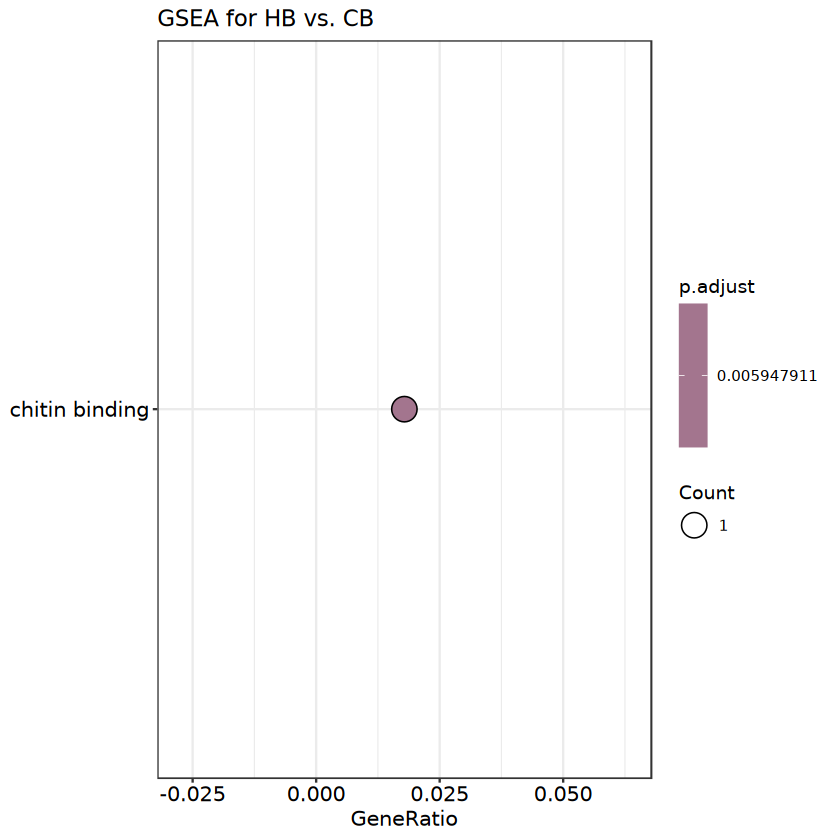

In [39]:
dotplot(gsea_res_hh.hc, showCategory=20) + ggtitle('GSEA for HB vs. CB')

In [40]:
# BB vs. BC
gsea_res_bb.bc <- GSEA(
    geneList = all_df$bc_bb,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_bb.bc))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.51% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched GO terms

### 7. Effect of initial single/multiple stress on response in ...

#### 7A. ...later *single* stress
- BH vs. HH
- BW vs. WW

In [41]:
# BH vs. HH
gsea_res_bh.hh <- GSEA(
    geneList = all_df$bh_hh,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_bh.hh))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.04% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
leading edge analysis...

done...



,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
GO:0042742,GO:0042742,defense response to bacterium,10,0.9937234,1.919697,2.626643e-05,0.003336194,0.003336194,31,"tags=10%, list=0%, signal=10%",LOC144620089
GO:0000086,GO:0000086,G2/M transition of mitotic cell cycle,10,-0.9948087,-1.858855,2.653037e-05,0.003336194,0.003336194,8,"tags=20%, list=0%, signal=20%",LOC111132547/LOC111132581
GO:0010971,GO:0010971,positive regulation of G2/M transition of mitotic cell cycle,10,-0.9948087,-1.858855,2.653037e-05,0.003336194,0.003336194,8,"tags=20%, list=0%, signal=20%",LOC111132547/LOC111132581
GO:0110032,GO:0110032,positive regulation of G2/MI transition of meiotic cell cycle,10,-0.9948087,-1.858855,2.653037e-05,0.003336194,0.003336194,8,"tags=20%, list=0%, signal=20%",LOC111132547/LOC111132581


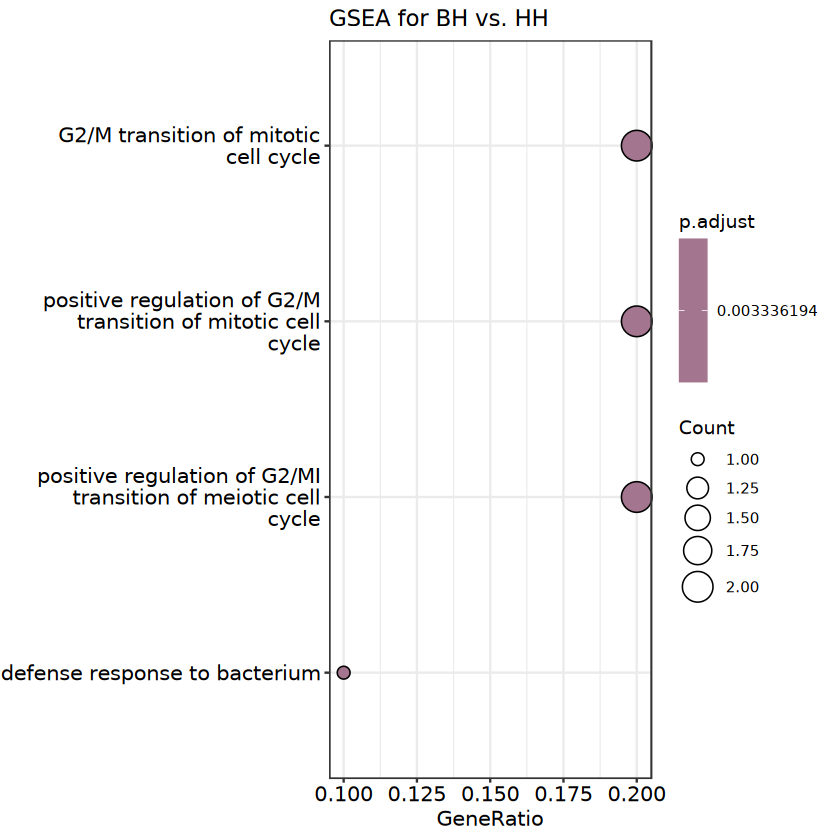

In [43]:
dotplot(gsea_res_bh.hh, showCategory=20) + ggtitle('GSEA for BH vs. HH')

see G2/M come up again - this came up in the comparison of CH vs. BH too - so could be a response to being primed with both warming and hypoxia before experiencing hypoxic stress later in life

In [44]:
# BW vs. WW
gsea_res_bw.ww <- GSEA(
    geneList = all_df$bw_ww,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_bw.ww))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.84% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
leading edge analysis...

done...



,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>
GO:0071949,GO:0071949,FAD binding,34,0.9937954,2.100942,6.804712e-05,0.0342277,0.0342277,6,"tags=6%, list=0%, signal=6%",LOC111113643/LOC144624000


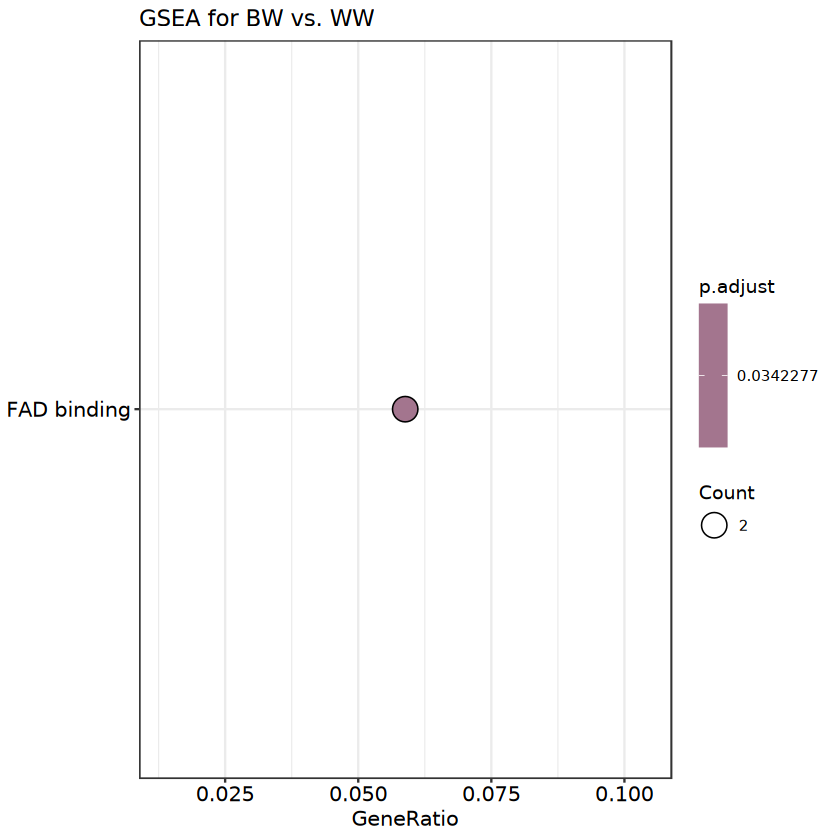

In [45]:
dotplot(gsea_res_bw.ww, showCategory=20) + ggtitle('GSEA for BW vs. WW')

FAD binding - proteins attach to Flavin Adenine Dinucleotide (FAD), a vital coenzyme used to drive oxidation-reduction reactions

#### 7B. ...later *multiple* stressors
- HB vs. BB
- WB vs. BB (no enriched terms)

In [47]:
# HB vs. BB
gsea_res_hb.bb <- GSEA(
    geneList = all_df$hb_bb,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_hb.bb))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.49% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
leading edge analysis...

done...



,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
GO:0006396,GO:0006396,RNA processing,25,-0.9995419,-1.458279,9.233401e-05,0.04644401,0.04644401,3,"tags=8%, list=0%, signal=8%",LOC111134475/LOC144617956


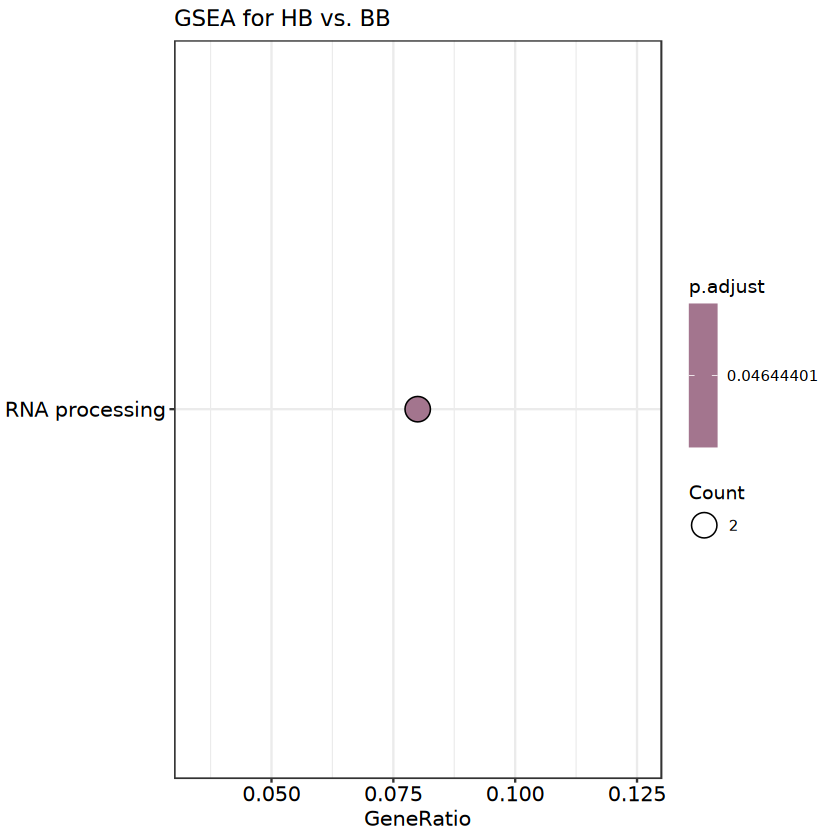

In [48]:
dotplot(gsea_res_hb.bb, showCategory=20) + ggtitle('GSEA for HB vs. BB')

In [49]:
# WB vs. BB
gsea_res_wb.bb <- GSEA(
    geneList = all_df$wb_bb,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_wb.bb))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.5% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched GO terms

### 8. Shared/unique response among stressors with ...

#### 8A. ...different *early* stressors
no enriched terms in any of these comparisons
- WC vs. HC 
- BC vs. HC
- BC vs. WC 

In [50]:
# WC vs. HC
gsea_res_wc.hc <- GSEA(
    geneList = all_df$wc_hc,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_wc.hc))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.54% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched GO terms

In [51]:
# BC vs. HC
gsea_res_bc.hc <- GSEA(
    geneList = all_df$bc_hc,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_bc.hc))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.03% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched GO terms

In [52]:
# BC vs. WC
gsea_res_bc.wc <- GSEA(
    geneList = all_df$bc_wc,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_bc.wc))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.05% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched GO terms

#### 8B. ...different *late* stressors
no enriched terms in any of these comparisons
- CW vs. CH
- CB vs. CH 
- CB vs. CW 


In [53]:
# CW vs. CH
gsea_res_cw.ch <- GSEA(
    geneList = all_df$cw_ch,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_cw.ch))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.55% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched GO terms

In [54]:
# CB vs. CH
gsea_res_cb.ch <- GSEA(
    geneList = all_df$cb_ch,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_cb.ch))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.54% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched GO terms

In [55]:
# CB vs. CW
gsea_res_cb.cw <- GSEA(
    geneList = all_df$cb_cw,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_cb.cw))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.73% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched GO terms

### 9. Effect of order of stressors on GE
- WH vs. HW (no enriched terms)
- WB vs. BW
- HB vs. BH

In [56]:
# WH vs. HW
gsea_res_wh.hw <- GSEA(
    geneList = all_df$wh_hw,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_wh.hw))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.5% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no enriched GO terms

In [57]:
# WB vs. BW
gsea_res_wb.bw <- GSEA(
    geneList = all_df$wb_bw,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_wb.bw))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.84% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
leading edge analysis...

done...



,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>
GO:0000086,GO:0000086,G2/M transition of mitotic cell cycle,10,0.9978095,1.733715,4.350748e-05,0.007294755,0.007294755,6,"tags=10%, list=0%, signal=10%",LOC111132581
GO:0010971,GO:0010971,positive regulation of G2/M transition of mitotic cell cycle,10,0.9978095,1.733715,4.350748e-05,0.007294755,0.007294755,6,"tags=10%, list=0%, signal=10%",LOC111132581
GO:0110032,GO:0110032,positive regulation of G2/MI transition of meiotic cell cycle,10,0.9978095,1.733715,4.350748e-05,0.007294755,0.007294755,6,"tags=10%, list=0%, signal=10%",LOC111132581


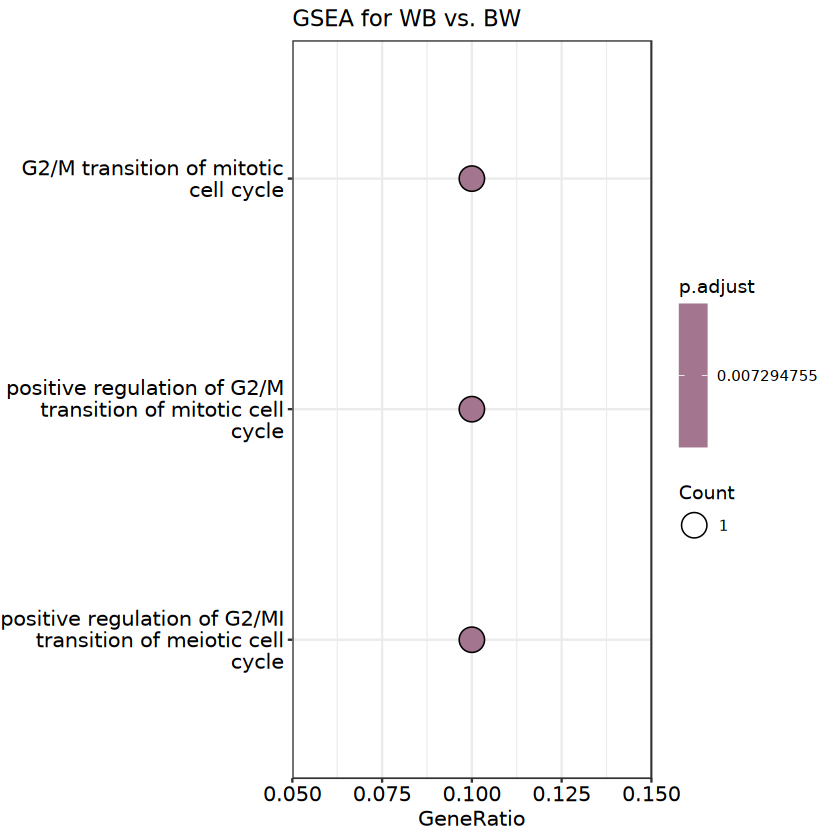

In [58]:
dotplot(gsea_res_wb.bw, showCategory=20) + ggtitle('GSEA for WB vs. BW')

G2/M transition again! seen in the comparisons CH vs. BH and BH vs. HH - so probably has something to do with this early both treatment

In [59]:
# HB vs. BH
gsea_res_hb.bh <- GSEA(
    geneList = all_df$hb_bh,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
head(as.data.frame(gsea_res_hb.bh))

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.47% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
leading edge analysis...

done...



,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
GO:0006513,GO:0006513,protein monoubiquitination,29,-0.9643482,-2.176106,9.363716e-05,0.04709949,0.04709949,92,"tags=10%, list=0%, signal=10%",LOC111115683/LOC144623333/LOC144627657


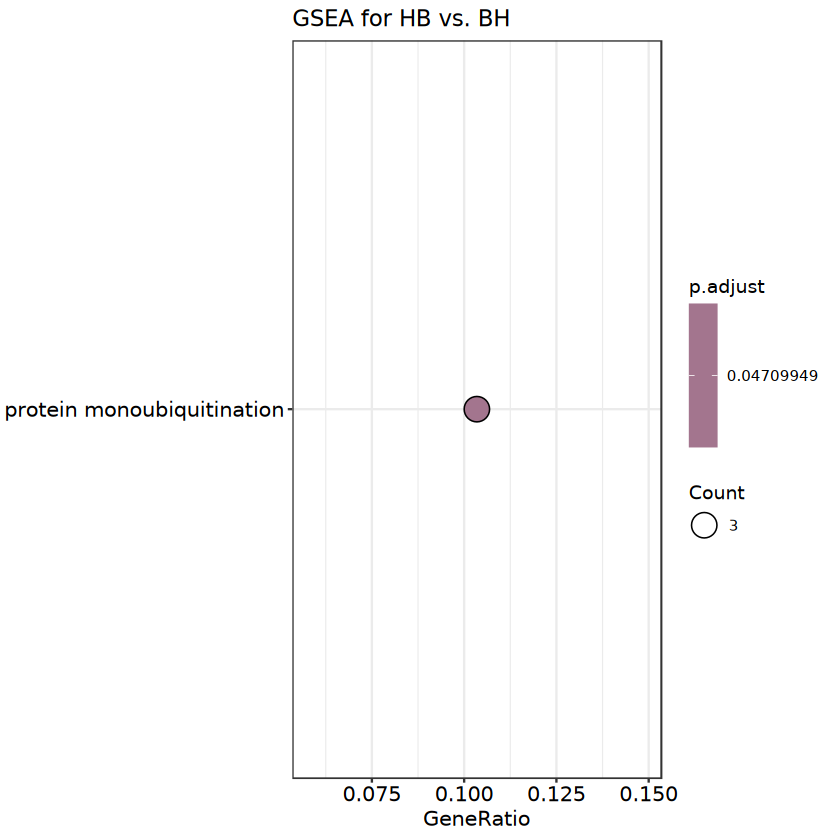

In [60]:
dotplot(gsea_res_hb.bh, showCategory=20) + ggtitle('GSEA for HB vs. BH')

protein monoubiquitination - "signal to trigger the regulated internalization of plasma membrane proteins" ([source](https://www.nature.com/articles/35056583)